C:\Users\ELCOT\AppData\Local\Temp\ipykernel_1620\1578832375.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


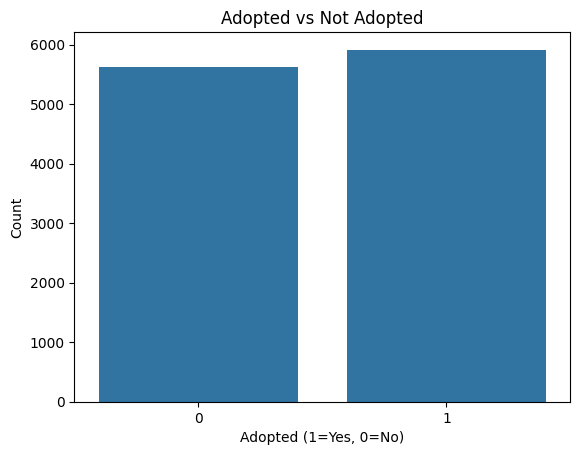

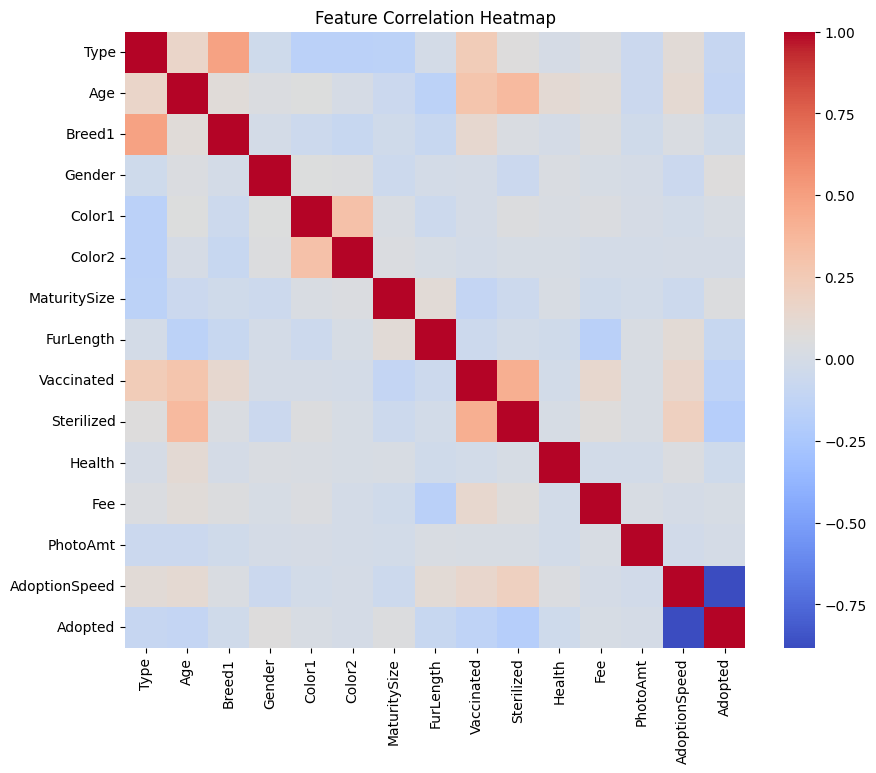

Accuracy: 0.5930098209127672
              precision    recall  f1-score   support

           0       0.62      0.47      0.53      1708
           1       0.58      0.71      0.64      1754

    accuracy                           0.59      3462
   macro avg       0.60      0.59      0.59      3462
weighted avg       0.60      0.59      0.59      3462



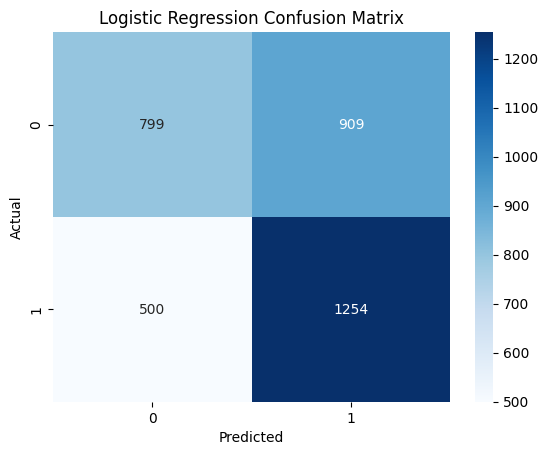

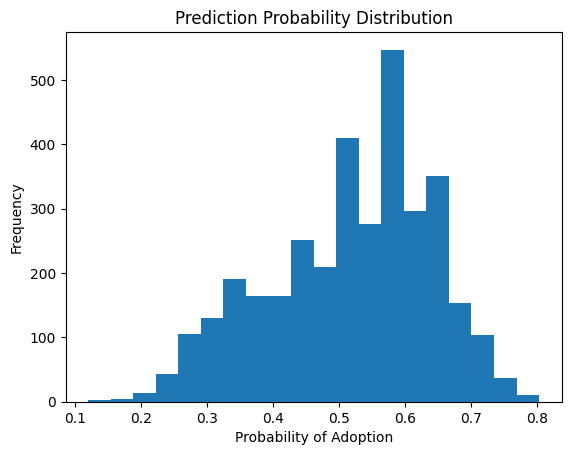

Prediction: This pet is likely to be ADOPTED


c:\Users\ELCOT\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


['logistic_model.joblib']

In [4]:
# ==============================
# LOGISTIC REGRESSION PROGRAM
# ==============================

# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load Dataset
df = pd.read_csv("petfinder-mini.csv")

# Remove unnecessary columns
df = df.drop(columns=['Name','PetID','Description'], errors='ignore')

# Handle missing values
df.fillna(0, inplace=True)

# Encode categorical data
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

# Convert AdoptionSpeed to Binary
df['Adopted'] = df['AdoptionSpeed'].apply(lambda x: 1 if x <=2 else 0)

# ==========================
# VISUALIZATION 1
# Adoption Distribution
# ==========================

plt.figure()
sns.countplot(x=df['Adopted'])
plt.title("Adopted vs Not Adopted")
plt.xlabel("Adopted (1=Yes, 0=No)")
plt.ylabel("Count")
plt.show()

# ==========================
# VISUALIZATION 2
# Correlation Heatmap
# ==========================

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# ==========================
# Prepare Data
# ==========================

X = df.drop(['AdoptionSpeed','Adopted'], axis=1)
y = df['Adopted']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ==========================
# Train Model
# ==========================

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# ==========================
# Prediction on Test Data
# ==========================

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# ==========================
# VISUALIZATION 3
# Confusion Matrix
# ==========================

plt.figure()
sns.heatmap(confusion_matrix(y_test,y_pred),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ==========================
# VISUALIZATION 4
# Prediction Probability
# ==========================

probabilities = model.predict_proba(X_test)

plt.figure()
plt.hist(probabilities[:,1], bins=20)
plt.title("Prediction Probability Distribution")
plt.xlabel("Probability of Adoption")
plt.ylabel("Frequency")
plt.show()

# ==========================
# NEW PET PREDICTION
# ==========================

# Example new pet data
new_pet = X.iloc[0].values.reshape(1,-1)

prediction = model.predict(new_pet)

if prediction[0] == 1:
    print("Prediction: This pet is likely to be ADOPTED")
else:
    print("Prediction: This pet is NOT likely to be adopted")

# Save the trained logistic regression model
joblib.dump(model, "logistic_model.joblib")